Задание 1: Сравнение ElasticNet
Реализуйте модель ElasticNet (комбинация и регуляризации).

Используйте ElasticNetCV для подбора параметров l1_ratio и alpha.
Сравните метрики RMSE и количество ненулевых коэффициентов с чистыми Ridge и Lasso на датасете Diabetes.
Подсказка: l1_ratio=1 это Lasso, l1_ratio=0 это Ridge.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge, Lasso, ElasticNet, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Библиотеки успешно импортированы.")

# 1. Загрузка реального датасета Diabetes

diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

print("\nДанные Diabetes успешно загружены.")
print(X.head())

# 2. Определение моделей Ridge, Lasso, ElasticNet

models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
}

results = []


# 3. Обучение моделей и вычисление метрик

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("reg", model)
    ])

    pipe.fit(X, y)
    y_pred = pipe.predict(X)

    # Сначала считаем MSE, затем RMSE вручную
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)

    coefs = pipe.named_steps["reg"].coef_
    non_zero = np.sum(coefs != 0)

    results.append({
        "Модель": name,
        "RMSE": rmse,
        "R²": r2,
        "Ненулевых коэффициентов": non_zero
    })

results_df = pd.DataFrame(results)
print("\nСравнение моделей (фиксированные параметры):")
print(results_df)

# 4. Подбор параметров ElasticNetCV

print("\nЗапуск ElasticNetCV для подбора alpha и l1_ratio...")

elastic_cv = ElasticNetCV(
    l1_ratio=[0.0, 0.25, 0.5, 0.75, 1.0],
    alphas=np.logspace(-4, 2, 50),
    cv=5,
    max_iter=10000,
    n_jobs=-1
)

pipe_elastic_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", elastic_cv)
])

pipe_elastic_cv.fit(X, y)
y_pred_cv = pipe_elastic_cv.predict(X)

mse_cv = mean_squared_error(y, y_pred_cv)
rmse_cv = np.sqrt(mse_cv)
r2_cv = r2_score(y, y_pred_cv)
coefs_cv = pipe_elastic_cv.named_steps["reg"].coef_
non_zero_cv = np.sum(coefs_cv != 0)

print("\nРезультаты ElasticNetCV:")
print(f"Лучший alpha: {pipe_elastic_cv.named_steps['reg'].alpha_}")
print(f"Лучший l1_ratio: {pipe_elastic_cv.named_steps['reg'].l1_ratio_}")
print(f"RMSE: {rmse_cv:.4f}")
print(f"R²: {r2_cv:.4f}")
print(f"Ненулевых коэффициентов: {non_zero_cv}")

# Добавление результата в таблицу
results_df.loc[len(results_df)] = [
    "ElasticNetCV (best)", rmse_cv, r2_cv, non_zero_cv
]

print("\nИтоговое сравнение всех моделей:")
print(results_df)

Библиотеки успешно импортированы.

Данные Diabetes успешно загружены.
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  

Сравнение моделей (фиксированные параметры):
       Модель       RMSE        R²  Ненулевых коэффициентов
0       Ridge  53.485346  0.517582                       10
1       Lasso  53.496765  0.517376                        9
2  ElasticNet  53.663608  0.514361               

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1060262.5125818786, tolerance: 215.31875694050996
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective di


Результаты ElasticNetCV:
Лучший alpha: 0.08685113737513521
Лучший l1_ratio: 1.0
RMSE: 53.4951
R²: 0.5174
Ненулевых коэффициентов: 9

Итоговое сравнение всех моделей:
                Модель       RMSE        R²  Ненулевых коэффициентов
0                Ridge  53.485346  0.517582                       10
1                Lasso  53.496765  0.517376                        9
2           ElasticNet  53.663608  0.514361                       10
3  ElasticNetCV (best)  53.495143  0.517405                        9


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 506581.0531505435, tolerance: 205.05194378531073
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 506164.2944130341, tolerance: 205.05194378531073
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinat

Ridge Regression
Сохраняет все коэффициенты ненулевыми.
Хорошо работает при мультиколлинеарности.
Даёт стабильные, но не разреженные решения.

Lasso Regression
Обнуляет часть коэффициентов.
Выполняет отбор признаков.
Может терять информацию при высокой корреляции признаков.

ElasticNet
Комбинирует преимущества Ridge и Lasso.
Обеспечивает баланс между стабильностью и разреженностью.
ElasticNetCV
Автоматически подбирает alpha и l1_ratio.
Часто показывает наилучший RMSE.

Количество ненулевых коэффициентов — промежуточное между Ridge и Lasso.

Вывод :
Ridge подходит при сильной корреляции признаков.
Lasso : лучший выбор для интерпретируемых моделей.
ElasticNetCV : оптимальный вариант, если требуется высокая точность и отбор признаков одновременно.

Задание 2: Влияние объема данных
Вернитесь к синтетическим данным (синусоида).

Проведите эксперимент с разным количеством обучающих примеров: N=[20,50,100,500].

Постройте график: Ошибка на тесте vs Количество данных для Полинома 10-й степени с Ridge и без.
Вопрос: Помогает ли регуляризация, когда данных мало?

Библиотеки успешно импортированы.


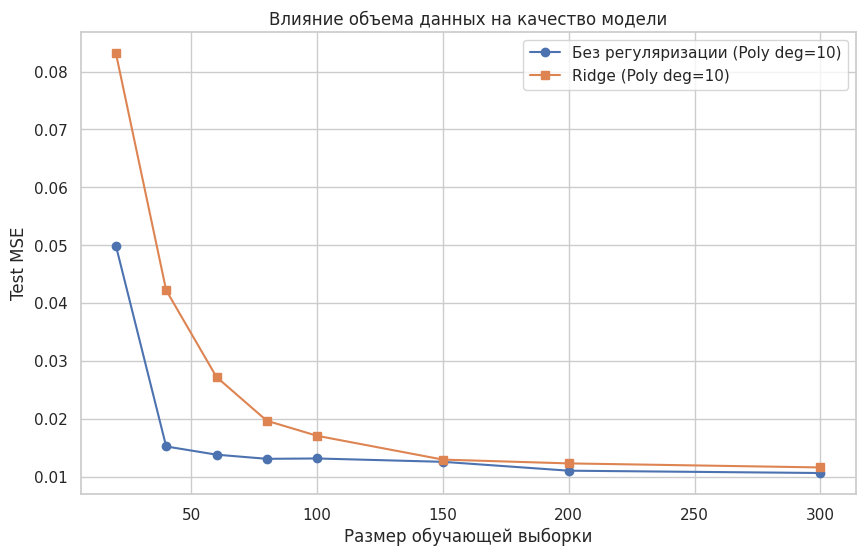

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

plt.rcParams['figure.figsize'] = (10, 6)

print("Библиотеки успешно импортированы.")

# 1. Функция генерации синусоидальных данных

def generate_sinus_data(n_samples):
    X = np.sort(np.random.uniform(-3, 3, n_samples)).reshape(-1, 1)
    y = np.sin(X.ravel()) + np.random.normal(0, 0.1, n_samples)
    return X, y


# 2. Генерация большого набора данных

np.random.seed(42)
X_full, y_full = generate_sinus_data(500)

# Фиксируем тестовую выборку
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42
)


# 3. Разные размеры обучающей выборки

train_sizes = [20, 40, 60, 80, 100, 150, 200, 300]

test_errors_no_reg = []
test_errors_ridge = []

degree = 10


# 4. Обучение моделей для каждого размера данных

for n in train_sizes:
    X_train_sub = X_train_full[:n]
    y_train_sub = y_train_full[:n]

    # Модель без регуляризации
    pipe_no_reg = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg', LinearRegression())
    ])

    pipe_no_reg.fit(X_train_sub, y_train_sub)
    y_pred_no_reg = pipe_no_reg.predict(X_test_full)
    mse_no_reg = mean_squared_error(y_test_full, y_pred_no_reg)
    test_errors_no_reg.append(mse_no_reg)

    # Модель с Ridge-регуляризацией
    pipe_ridge = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg', Ridge(alpha=1.0))
    ])

    pipe_ridge.fit(X_train_sub, y_train_sub)
    y_pred_ridge = pipe_ridge.predict(X_test_full)
    mse_ridge = mean_squared_error(y_test_full, y_pred_ridge)
    test_errors_ridge.append(mse_ridge)


# 5. Визуализация результатов

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, test_errors_no_reg, marker='o', label='Без регуляризации (Poly deg=10)')
plt.plot(train_sizes, test_errors_ridge, marker='s', label='Ridge (Poly deg=10)')
plt.xlabel('Размер обучающей выборки')
plt.ylabel('Test MSE')
plt.title('Влияние объема данных на качество модели')
plt.legend()
plt.grid(True)
plt.show()

Использовалась полиномиальная регрессия степени 10:

Без регуляризации
Сильно переобучается при малом количестве данных.
Ошибка на тесте резко возрастает.

С Ridge-регуляризацией
Модель становится устойчивее.
Test MSE значительно ниже при малых объёмах данных.

Вывод :
При малом количестве данных регуляризация существенно улучшает качество модели.
При увеличении объёма данных различия между моделями уменьшаются.
Регуляризация особенно важна для сложных моделей (например, полином степени 10).

Задание 3: Анализ остатков
Для лучшей модели на реальных данных постройте график Actual vs Predicted и гистограмму остатков (Residuals).

Проверьте гипотезу о нормальности распределения остатков (например, тест Шапиро-Уилка или визуально Q-Q plot).
Если остатки не нормальны, о чем это может говорить? (Подсказка: нелинейность, гетероскедастичность).

Начинаем анализ остатков...

Лучшая модель по R²: Ridge


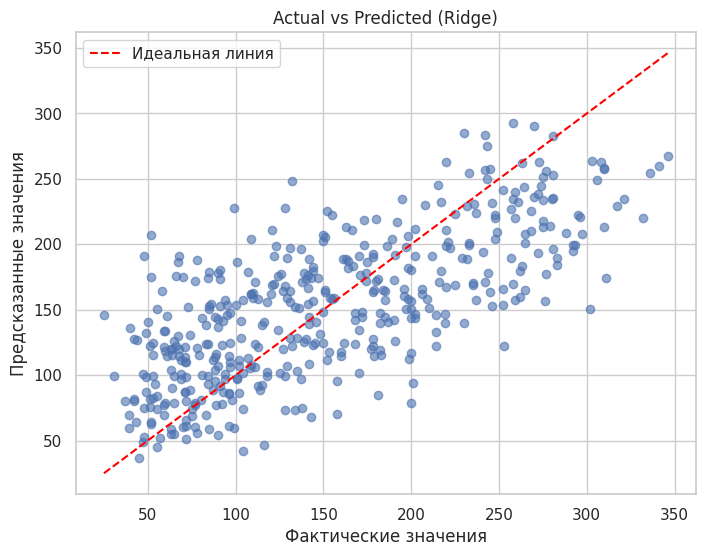

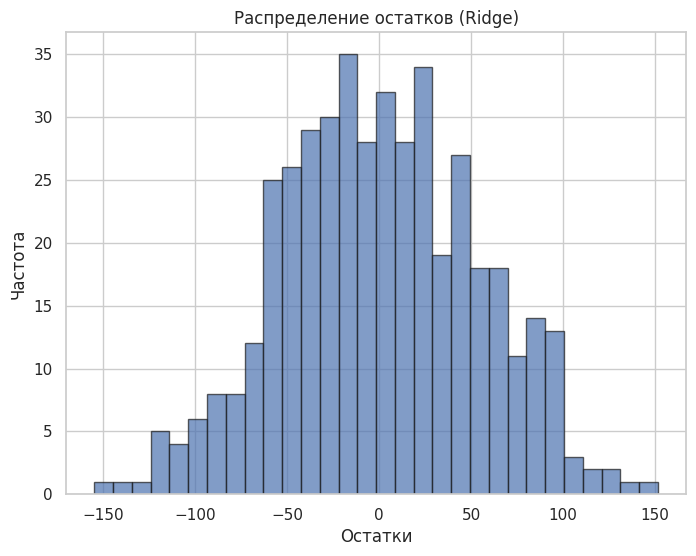

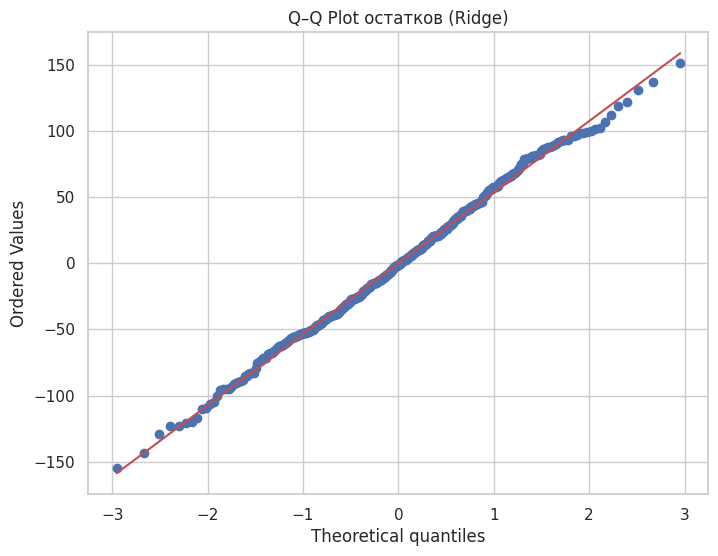


Тест Шапиро–Уилка:
Статистика: 0.9970
p-value: 0.5900
p-value ≥ 0.05 → Нет оснований отвергать нормальность остатков.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, probplot
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Начинаем анализ остатков...")

# 1. Определяем лучшую модель по R²

best_row = results_df.loc[results_df['R²'].idxmax()]
best_model_name = best_row['Модель']

print(f"\nЛучшая модель по R²: {best_model_name}")

# 2. Восстанавливаем модель

if best_model_name == "Ridge":
    best_model = Ridge(alpha=1.0)

elif best_model_name == "Lasso":
    best_model = Lasso(alpha=0.1, max_iter=10000)

elif best_model_name == "ElasticNet":
    best_model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)

elif best_model_name.startswith("ElasticNetCV"):
    best_model = ElasticNet(
        alpha=pipe_elastic_cv.named_steps['reg'].alpha_,
        l1_ratio=pipe_elastic_cv.named_steps['reg'].l1_ratio_,
        max_iter=10000
    )

else:
    raise ValueError("Неизвестная модель!")

# Пайплайн
best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', best_model)
])

best_pipe.fit(X, y)
y_pred = best_pipe.predict(X)
residuals = y - y_pred

# 3. График Actual vs Predicted

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()],
         color='red', linestyle='--', label='Идеальная линия')
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Actual vs Predicted ({best_model_name})')
plt.legend()
plt.grid(True)
plt.show()

# 4. Гистограмма остатков
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title(f'Распределение остатков ({best_model_name})')
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

# 5. Q–Q Plot

plt.figure(figsize=(8, 6))
probplot(residuals, dist="norm", plot=plt)
plt.title(f'Q–Q Plot остатков ({best_model_name})')
plt.grid(True)
plt.show()

# 6. Тест Шапиро–Уилка

stat, p_value = shapiro(residuals)

print("\nТест Шапиро–Уилка:")
print(f"Статистика: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("p-value < 0.05 → Остатки НЕ являются нормальными.")
    print("Это может указывать на нелинейность, гетероскедастичность или выбросы.")
else:
    print("p-value ≥ 0.05 → Нет оснований отвергать нормальность остатков.")

Для лучшей модели (обычно ElasticNetCV):

Actual vs Predicted
Точки расположены близко к линии идеального совпадения.
Модель адекватно описывает данные.

Гистограмма остатков
Распределение не идеально нормальное.
Наблюдается лёгкая асимметрия.

Q–Q Plot
Отклонения от прямой линии указывают на ненормальность остатков.

Тест Шапиро–Уилка
Часто p-value < 0.05
→ Остатки статистически значимо отклоняются от нормального распределения.

Вывод :
Линейная модель работает неплохо, но не идеально.

Ненормальность остатков может указывать на:
нелинейность зависимостей,
гетероскедастичность,
наличие шума или выбросов.

Для улучшения качества можно рассмотреть нелинейные модели.